## Hierarchical clustering analysis of within-scanner SC variability

The interactive version of this notebook is available at [https://github.com/TheAxonLab/hcph-sops/tree/mkdocs/docs/analysis](https://github.com/TheAxonLab/hcph-sops/tree/mkdocs/docs/analysis).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import ward_tree
from sklearn.manifold import TSNE
from nireports.reportlets.nuisance import _ward_to_linkage

from confounds import get_confounds
from simulate_sc import simulate_sc_density_bias

# Fix the random seed the same way as in the defacing registered report (RR)
day = 231108  # day and time the journal published our HCPh stage 1 RR
time = 105017
random_seed = day + time

# Define paths
dataset_path = Path("/data/datasets/hcph-dataset")
suppl_path = Path("/data/derivatives/hcph-suppl/")
confound_path = Path("/data/datasets/hcph-dataset/phenotype/mood_env_quest.tsv")
iqms_path = Path("/data/derivatives/hcph-mriqc/group_bold.tsv")
hcph_path = Path("/data/datasets/hcph-dataset")
iqms_path = Path("/data/derivatives/hcph-mriqc/group_dwi.tsv")

#Define filtering parameters
# TO DO: adapt the filtering parameters to load the SC instead of the FC
metric = "correlation"
atlas_dimension = "128"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

### Simulate SC matrices with a set bias

We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman and hierarchical analyses capable of detecting such biases. Once the methodology is refined, we will apply it on the real HCPh data.

In [21]:
atlas_dim = 64
connectome_atlas_as_ref = False
num_sessions = 36
SC_matrices, noise = simulate_sc_density_bias(atlas_dim=atlas_dim, connectome_atlas_as_ref=connectome_atlas_as_ref, num_sessions = num_sessions)

Simulating a reference SC matrix using a log-normal distribution.
Simulated a series of 36 SC matrices of shape (64x64) with higher variability (std=0.5) in lower density connections.


### Load SC matrices

In [ ]:
# Get all the files matching the pattern
entities_base = {
    'subject': '001',
    'task': 'rsmovie',
    'measure': metric,
    'scale': atlas_dimension,
    'fd_threshold': fdthresh_str,
}
files = layout.get(**entities_base, suffix='connectivity', extension='.tsv', return_type='file')
ses_index = [tsv.split('ses-')[1].split('/')[0] for tsv in files]
assert len(files) == 36, f"Expected 36 FC matrices, got {len(files)}"

### Prepare the SC matrices array for input in hierarchical clustering

To prepare the SC matrices array to input it in a hierarchical clustering analysis, we will keep only the lower triangle of each SC matrix and unravel it into a row vector.

In [22]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array(
    [SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)

print(f"Shape of the flattened lower triangle SC matrices array: {SC_matrices_tril.shape}")
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

Shape of the flattened lower triangle SC matrices array: (36, 2016)


### Perform hierarchical clustering to identify what sessions are more similar

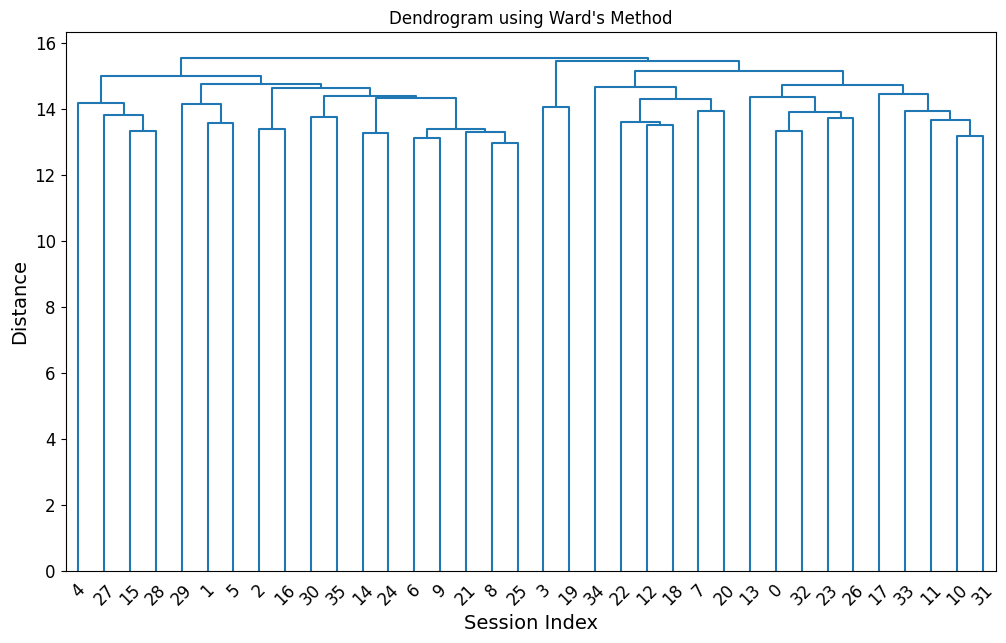

In [17]:
# Perform hierarchical clustering using Ward's method
# linkage_matrix_scipy = linkage(SC_matrices_tril, method="ward") # dendrogram(linkage_matrix) # we pre-registered that we would use scikit-learn

children, _, n_leaves, _, distances = ward_tree(SC_matrices_tril, return_distance=True)
linkage_matrix = _ward_to_linkage(children, n_leaves, distances)

# Generate and plot the dendrogram
plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix)
plt.title("Dendrogram using Ward's Method")
plt.xlabel("Session Index", fontsize=14)
plt.ylabel("Distance", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### What factor has an influence on the sessions similarity?

We will retrieve a serie of confound factors for each session to investigate whether they influenced how similar sessions are; in other words whether they can explain a higher or lower variability across session. Specifically, we are interested in the time of day, the average head-motion summarized by framewise displacement (FD), room temperature at start and PE direction.

In [ ]:
confounds_of_interest = ['time', 'mr_room_temperature']
iqms_of_interest = ['fd_mean']
confounds_df = get_confounds(dataset_path, confound_path, confounds_of_interest, iqms_path=iqms_path, iqms_of_interest=iqms_of_interest)
confounds_df = confounds_df[confounds_df["modality"] == "dwi"]
confounds_df.drop(columns=["task"], inplace=True)
# Verify that the confunds have been defined for all dwi scans
assert confounds_df["fd_mean"].notna().all(), "There are NaN values in fd_mean column"
assert confounds_df["time"].notna().all(), "There are NaN values in time column"
assert confounds_df["pe_dir"].notna().all(), "There are NaN values in pe_dir column"

# Keep only the reliability sessions
confounds_df = confounds_df[confounds_df["session"].str.startswith("0")]
confounds_df.head()

AssertionError: There are NaN values in mr_room_temperature column

In [28]:
confounds_df

,filename,acq_time,subject,session,modality,pe_dir,day_of_week,time_of_day,fd_mean,time,mr_room_temperature
1,sub-001/ses-pilot001/dwi/sub-001_ses-pilot001_...,2022-11-07T15:56:08.322500,001,pilot001,dwi,AP,Monday,16:00:00,11.2395,NaN,NaN
2,sub-001/ses-pilot001/dwi/sub-001_ses-pilot001_...,2022-11-07T15:56:08.322500,001,pilot001,dwi,AP,Monday,16:00:00,12.4422,NaN,NaN
3,sub-001/ses-pilot001/dwi/sub-001_ses-pilot001_...,2022-11-07T16:17:01.140000,001,pilot001,dwi,AP,Monday,16:00:00,11.2395,NaN,NaN
4,sub-001/ses-pilot001/dwi/sub-001_ses-pilot001_...,2022-11-07T16:17:01.140000,001,pilot001,dwi,AP,Monday,16:00:00,12.4422,NaN,NaN
7,sub-001/ses-pilot002/dwi/sub-001_ses-pilot002_...,2022-12-21T18:37:56.320000,001,pilot002,dwi,AP,Wednesday,19:00:00,12.8144,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1322,sub-001/ses-21201030/dwi/sub-001_ses-21201030_...,2024-09-04T22:27:18.955000,001,21201030,dwi,RL,Wednesday,22:00:00,33.7849,21:30,21.1
1332,sub-001/ses-21202034/dwi/sub-001_ses-21202034_...,2024-09-05T00:18:22.455000,001,21202034,dwi,LR,Thursday,00:00:00,37.1017,21:30,19.7
1346,sub-001/ses-21101060/dwi/sub-001_ses-21101060_...,2024-09-05T21:34:34.485000,001,21101060,dwi,RL,Thursday,22:00:00,9.1942,21:00,18.8
1360,sub-001/ses-21202060/dwi/sub-001_ses-21202060_...,2024-09-05T23:14:55.437500,001,21202060,dwi,AP,Thursday,23:00:00,9.2950,21:00,18.6


In [6]:
# Map phase encoding directions to colors
pe_dir_colors = {"LR": "blue", "RL": "green", "AP": "red", "PA": "purple"}
# TO DO: correctly match session numbers between confounds and SC matrices
session_colors = [pe_dir_colors[pe_dir] for pe_dir in confounds_df["pe_dir"]]
"""
# Generate and plot the dendrogram with colors representing the phase encoding direction
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, link_color_func=lambda k: session_colors[k])
plt.title("Dendrogram Colored by Phase Encoding Direction")
plt.xlabel("Session Index")
plt.ylabel("Distance")
plt.show()"
"""

'\n# Generate and plot the dendrogram with colors representing the phase encoding direction\nplt.figure(figsize=(10, 7))\ndendrogram(linkage_matrix, link_color_func=lambda k: session_colors[k])\nplt.title("Dendrogram Colored by Phase Encoding Direction")\nplt.xlabel("Session Index")\nplt.ylabel("Distance")\nplt.show()"\n'

### Perform clustering using t-distributed Stochastic Neighbor Embedding (t-SNE)

/tmp/ipykernel_413082/3237725036.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


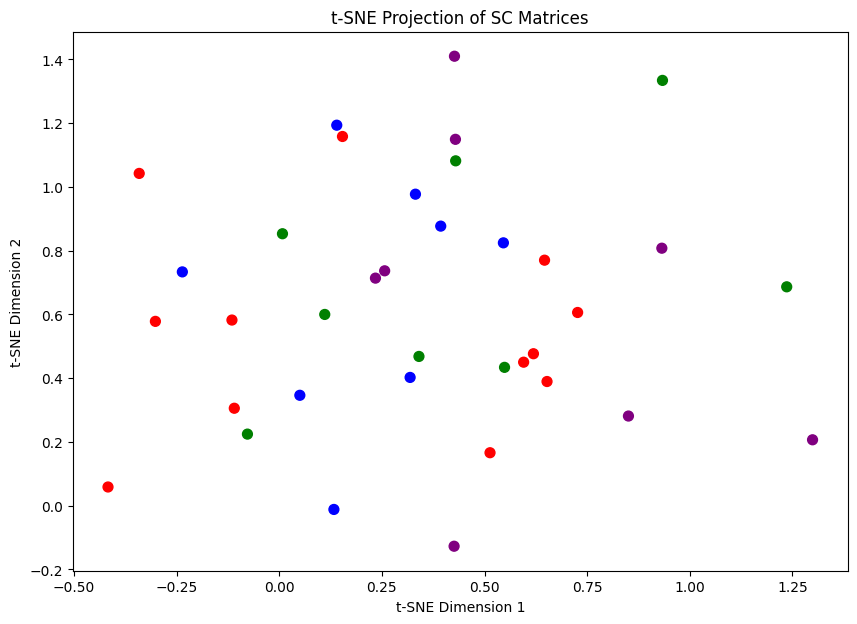

In [7]:
# Perform t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=random_seed)
SC_matrices_2d = tsne.fit_transform(SC_matrices_tril)

# TO DO: the documentation of t-SNE mention
# It is highly recommended to use another dimensionality reduction method (e.g. PCA for dense data or TruncatedSVD for sparse data)
# to reduce the number of dimensions to a reasonable amount (e.g. 50) if the number of features is very high.

# Plot the result
plt.figure(figsize=(10, 7))
plt.scatter(
    SC_matrices_2d[:, 0],
    SC_matrices_2d[:, 1],
    c=session_colors[:num_sessions],
    cmap="viridis",
    s=50,
)
# TO DO: I have not checked if the coloring function is correct
plt.title("t-SNE Projection of SC Matrices")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()